In [16]:
#importamos las bibliotecas que necesitaremos 
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
%matplotlib inline 

In [17]:
# Las ecuaciones diferenciales del modelo SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N             #S'(t)
    dIdt = beta * S * I / N - gamma * I  #I'(t)
    dRdt = gamma * I                     #R'(t)
    return dSdt, dIdt, dRdt

In [18]:
def plot(S, I, R, t, divide_by=1):
    # Dibujamos los datos de S(t), I(t) y R(t)
    fig, ax = plt.subplots()
    ax.plot(t, S / divide_by, 'b', alpha=0.5, lw=3, label='Susceptible')
    ax.plot(t, I / divide_by, 'r', alpha=0.5, lw=3, label='Infectado')
    ax.plot(t, R / divide_by, 'g', alpha=0.5, lw=3, label='Recuperado con inmunidad')
    ax.set_xlabel('Tiempo /días')
    ax.set_ylabel('Población')
    legend = ax.legend(loc = 'best')
    #fig.show() # descomenta esto si no estás en Jupyter

In [19]:
N = 47_000_000 # poblacion inicial 
I0 = 10_000    #infectados iniciales
R0 = 0         #recuperados iniciales 
S0 = N - I0 - R0  #suceptibles iniciales, obs que casi todo N es suceptible de infectarse
 
beta = 0.1   # contagio
gamma = 0.02 # recuperación
beta/gamma   # tasa de rep basica

t = np.linspace(0, 365, 365) #tiempo en este caso es un año 
y0 = S0, I0, R0 #condiciones inciales 

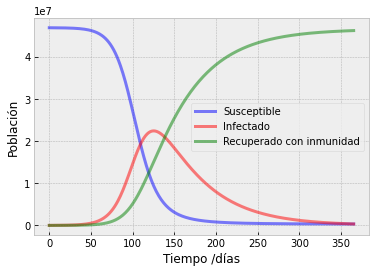

In [21]:
#integramos 
ret = odeint(deriv, y0, t, args=(N, beta, gamma))
S, I, R = ret.T
 
plot(S, I, R, t) # Datos sin dividir entre la poblacion